
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b> <a class="tocSkip"></a>

¡Hola Salvador!

Gracias por realizar las correcciones solicitadas en la revisión anterior. Verifiqué los puntos rojos pendientes y ya ajustaste correctamente el conteo de personas únicas en [A2] y [A3], así como la tabla de tasa de reorden por producto en [C3].

El proyecto queda aprobado. Como recomendación para próximos proyectos, mantén esta buena práctica: cuando el enunciado pida personas/clientes, usa identificadores únicos como `user_id`; cuando pida pedidos o productos, usa el identificador correspondiente al nivel de análisis.

Saludos,  
Gina Buvoli
</div>


# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.
El primer paso es familiarizarse con los datos. Esto implica cargar los cinco archivos CSV en DataFrames de Pandas y utilizar el método .info() para obtener una visión general de cada uno. Se revisará el número de filas y columnas, los tipos de datos de cada columna y la presencia de valores no nulos para identificar problemas iniciales como datos faltantes o tipos de datos incorrectos.

In [2]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [4]:
# mostrar información del DataFrame
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [5]:
# mostrar información del DataFrame
print(products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [6]:
# mostrar información del DataFrame
print(aisles.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [7]:
# mostrar información del DataFrame
print(departments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [8]:
# mostrar información del DataFrame
print(order_products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Tras cargar y examinar los conjuntos de datos (orders, products, aisles, departments y order_products), se observa lo siguiente:

Volumen y estructura:
Cada DataFrame contiene entre decenas de miles a cientos de miles de filas, lo que refleja la escala de las transacciones de Instacart. Las columnas son claras y consistentes, con identificadores únicos para órdenes, productos y usuarios.

Tipos de datos:
Las columnas de identificación (order_id, user_id, product_id, etc.) en general están en formatos numéricos adecuados, aunque se verificará que todos estén en tipo entero para evitar inconsistencias.

Valores nulos y duplicados:
Inicialmente, no se detectaron valores ausentes significativos ni duplicados evidentes en los DataFrames principales, lo que indica buena calidad inicial de los datos, aunque se realizará un análisis más detallado en el siguiente paso.

Relaciones entre tablas:
La estructura permite unir las tablas mediante llaves foráneas claras, como product_id y aisle_id, facilitando análisis conjuntos sobre productos, departamentos y órdenes.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El Paso 1 se completó con éxito: cargaste los cinco conjuntos de datos con los parámetros adecuados de `read_csv` y usaste las salidas de `info()` para resumir claramente las dimensiones (shapes), los dtypes y las señales iniciales de valores faltantes para cada tabla.

</div>


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.
El objetivo de este paso es limpiar los datos para asegurar su calidad antes del análisis. El plan consiste en abordar sistemáticamente tres áreas:

Duplicados: Se buscarán y eliminarán filas duplicadas en cada DataFrame. Se prestará especial atención a duplicados basados en subconjuntos de columnas (como order_id o product_name) para detectar inconsistencias.

Valores Ausentes: Se investigará la naturaleza de los valores ausentes en las columnas identificadas (days_since_prior_order, product_name y add_to_cart_order). Se decidirá una estrategia de imputación (relleno) o eliminación basada en el contexto de los datos.

Tipos de Datos: Se corregirán los tipos de datos de las columnas que lo necesiten, por ejemplo, convirtiendo columnas de ID a enteros después de manejar los valores ausentes, para optimizar el uso de memoria y la consistencia.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [9]:
# Revisa si hay pedidos duplicados
duplicated_rows = orders[orders.duplicated()]
print(f"Número de filas duplicadas: {len(duplicated_rows)}")

Número de filas duplicadas: 15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Sí, existen 15 filas completamente duplicadas en el DataFrame. Lo que tienen en común es que comparten exactamente los mismos valores en absolutamente todas sus columnas. Es decir, se repite el mismo order_id para el mismo user_id con el mismo order_number. Además, el patrón clave que comparten estos 15 registros idénticos es que todos fueron registrados exactamente el mismo día y a la misma hora: los miércoles a las 2:00 a.m. 

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu respuesta es demasiado breve para el prompt. Considera indicar explícitamente que existen duplicados (cuántos) y describir qué comparten basándote en las filas duplicadas en sí (p. ej., mismo `order_dow`/`order_hour_of_day`, `order_id` repetido, etc.).

</div>


In [10]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
# 1. Primero inspeccionamos el subconjunto exacto de filas duplicadas
filas_duplicadas = orders[orders.duplicated()]
print(f"Total de filas duplicadas encontradas: {len(filas_duplicadas)}")
print("Muestra de los duplicados:")
display(filas_duplicadas)

# 2. Comprobamos si todas estas filas duplicadas ocurrieron el miércoles a las 2:00 a.m.
duplicados_miercoles_2am = filas_duplicadas[(filas_duplicadas['order_dow'] == 3) & (filas_duplicadas['order_hour_of_day'] == 2)]

print(f"\nDe las {len(filas_duplicadas)} filas duplicadas en total, {len(duplicados_miercoles_2am)} ocurrieron el miércoles a las 2:00 a.m.")

Total de filas duplicadas encontradas: 15
Muestra de los duplicados:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN



De las 15 filas duplicadas en total, 15 ocurrieron el miércoles a las 2:00 a.m.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este es un buen comienzo, pero no confirma si las filas duplicadas son específicamente los pedidos del miércoles a las 2:00 a.m. Sería más claro inspeccionar primero el subconjunto duplicado y luego comprobar sus valores de `order_dow`/`order_hour_of_day` (y/o compararlo con el filtro de miércoles-2am).

</div>


¿Qué sugiere este resultado?

El hecho de que absolutamente todas las filas duplicadas ocurran en un único bloque temporal muy específico (miércoles a las 2:00 a.m.) sugiere fuertemente que se trata de un error técnico del sistema y no de un comportamiento humano real.

Este patrón de timestamps apunta a las siguientes causas plausibles en la recolección de datos:

1. Mantenimiento o reinicio de servidores: Las 2:00 a.m. es un horario clásico de bajo tráfico donde las empresas programan mantenimientos. Una interrupción o reinicio del servidor en ese momento pudo haber provocado que las transacciones en curso se insertaran dos veces en la base de datos.

2. Errores en trabajos programados (CRON jobs / Logging): Es muy probable que un script automatizado de respaldo, sincronización o importación de datos estuviera programado para ejecutarse el miércoles a las 2:00 a.m. Si el script falló a la mitad o se ejecutó dos veces por accidente, duplicaría exactamente ese lote de registros.

3. Fallo momentáneo de red: Un glitch de conexión a esa hora que provocó que el sistema no recibiera la confirmación de la orden, haciendo que la aplicación reenviara la solicitud de compra por duplicado.

En conclusión, la concentración de duplicados en este momento específico indica una anomalía de software o infraestructura, validando que eliminar estas filas es la decisión correcta para no sesgar el análisis.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu interpretación se centra en la “actividad a las 2 a.m.”, pero la pregunta está pidiendo qué sugiere el resultado de las 2 a.m. del miércoles sobre los duplicados. Considera conectar este patrón de timestamps con un mecanismo plausible de creación de duplicados (p. ej., un problema de logging/importación en ese día/hora específicos).

</div>


In [11]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()


In [12]:
# Vuelve a verificar si hay filas duplicadas
num_duplicados_despues = orders.duplicated().sum()
print(f"Número de filas duplicadas después de eliminar: {num_duplicados_despues}")

Número de filas duplicadas después de eliminar: 0


In [13]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
duplicated_order_ids = orders['order_id'].duplicated().sum()
print(f"Número de order_id duplicados: {duplicated_order_ids}")

Número de order_id duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Hallazgos: Se identificaron originalmente 15 filas completamente duplicadas en el DataFrame orders. Al realizar una comparación directa aislando el subconjunto de duplicados contra los pedidos del miércoles a las 2:00 a.m., se descubrió una relación del 100%: las 15 filas duplicadas pertenecen de forma exclusiva a ese bloque horario específico (miércoles, 2:00 a.m.). Esto comprueba un patrón sistemático ligado a un fallo técnico (como un error de importación de datos o un script automatizado duplicado a esa hora) y no a un comportamiento aleatorio del usuario.

Acciones tomadas: Eliminé de forma definitiva las 15 filas duplicadas exactas utilizando el método drop_duplicates(). Posteriormente, volví a verificar el DataFrame y se confirmó que el número de filas totalmente duplicadas y de IDs de pedidos (order_id) repetidos se redujo exitosamente a 0, garantizando la integridad de los datos para el análisis posterior.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Mencionas que la investigación del miércoles a las 2 a.m. no reveló un patrón, pero en realidad no comparas las filas duplicadas con el subconjunto de Wednesday-2am. Sería más sólido indicar explícitamente qué comparaste y qué concluiste sobre su relación.

</div>


### `products` data frame

In [14]:
# Verifica si hay filas totalmente duplicadas
duplicated_rows = products.duplicated().sum()
print(f"Número de filas totalmente duplicadas en 'products': {duplicated_rows}")

Número de filas totalmente duplicadas en 'products': 0


In [15]:
# Revisa únicamente si hay ID de productos duplicados
duplicated_product_ids = products['product_id'].duplicated().sum()
print(f"Número de product_id duplicados: {duplicated_product_ids}")

Número de product_id duplicados: 0


In [16]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
product_names_upper = products['product_name'].str.upper()

# Verificar cuántos nombres están duplicados (en mayúsculas)
duplicated_names = product_names_upper.duplicated().sum()
print(f"Número de nombres de productos duplicados: {duplicated_names}")

Número de nombres de productos duplicados: 1361


In [17]:
# Revisa si hay nombres duplicados de productos no faltantes
valid_names = products['product_name'].dropna()

# Convertir a mayúsculas para comparación uniforme
valid_names_upper = valid_names.str.upper()

# Contar cuántos nombres están duplicados
duplicated_names = valid_names_upper.duplicated().sum()
print(f"Número de nombres de productos duplicados (excluyendo faltantes): {duplicated_names}")

Número de nombres de productos duplicados (excluyendo faltantes): 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Filas totalmente duplicadas: No se encontraron filas completamente duplicadas (el resultado de la validación fue 0). Por lo tanto, el DataFrame ya estaba limpio a nivel de registros enteros y no fue necesario realizar ninguna eliminación.

IDs de productos (product_id) duplicados: No se encontraron IDs repetidos. Esto confirma que la estructura del catálogo es correcta y cada artículo posee un identificador único.

Nombres de productos duplicados: Al estandarizar el texto a letras mayúsculas para evitar errores tipográficos, se detectaron 1,361 repeticiones en total. Al excluir los valores nulos, confirmamos la existencia de 104 nombres de productos duplicados válidos.

Decisión y acciones tomadas: Se tomó la decisión de conservar estos 104 registros. En un catálogo de ventas, es completamente normal que distintos identificadores (product_id) compartan el mismo nombre general si corresponden a diferentes variantes, presentaciones, tamaños o empaques del mismo producto que no fueron detallados en el texto. Dado que su ID único intacto es lo que se usa para cruzar los datos de las órdenes, estos nombres repetidos no afectan la integridad del análisis.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu resumen escrito no coincide con tus resultados calculados: tus comprobaciones muestran 0 filas totalmente duplicadas en `products`, así que evita afirmar que las encontraste/eliminaste. Además, después de identificar muchos nombres de producto duplicados sin distinguir mayúsculas y minúsculas (case-insensitive), añade una breve decisión sobre cómo los vas a manejar (p. ej., conservarlos porque distintos valores de `product_id` pueden compartir legítimamente un nombre, o marcarlos para una investigación más profunda).

</div>


### `departments` data frame

In [18]:
# Revisa si hay filas totalmente duplicadas
print(f"Duplicados en departments: {departments.duplicated().sum()}")

Duplicados en departments: 0


In [19]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(f"IDs duplicados en departments: {departments['department_id'].duplicated().sum()}")

IDs duplicados en departments: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

El DataFrame departments está limpio en términos de duplicados. No se encontraron filas completas duplicadas ni department_id repetidos. Dado que la tabla es una tabla de dimensiones simple y pequeña (contiene solo 21 departamentos), este resultado es el esperado. No se requirió ninguna acción de limpieza.

### `aisles` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
print(f"Duplicados en aisles: {aisles.duplicated().sum()}")

Duplicados en aisles: 0


In [21]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(f"IDs duplicados en aisles: {aisles['aisle_id'].duplicated().sum()}")

IDs duplicados en aisles: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al igual que con el DataFrame departments, el DataFrame aisles no contiene filas completamente duplicadas ni IDs de pasillo (aisle_id) repetidos. Esta tabla de dimensiones, que mapea los IDs a los nombres de los pasillos, está correctamente estructurada y limpia. Por lo tanto, no fue necesaria ninguna acción de limpieza.

### `order_products` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
print(f"Duplicados en order_products: {order_products.duplicated().sum()}")

Duplicados en order_products: 0


In [23]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(f"Duplicados engañosos en order_products: {order_products.duplicated(subset=['order_id', 'product_id']).sum()}")

Duplicados engañosos en order_products: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

El DataFrame order_products, que es el más grande del conjunto de datos, está libre de duplicados.

No se encontraron filas totalmente duplicadas.

Una verificación más específica para "duplicados engañosos" (casos en los que el mismo producto aparece más de una vez en el mismo pedido) también arrojó cero resultados.

Estos hallazgos confirman que cada entrada en esta tabla representa de manera única un producto específico dentro de un pedido. Como no se encontraron duplicados, no fue necesario realizar ninguna acción de limpieza.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [24]:
# Encuentra los valores ausentes en la columna 'product_name'
# Contar el número de valores ausentes
missing_product_names = products['product_name'].isnull().sum()
print(f"Número de nombres de producto ausentes: {missing_product_names}")

# Mostrar algunas filas con nombres de producto ausentes
print("\nEjemplos de productos con nombre ausente:")
print(products[products['product_name'].isnull()].head())

Número de nombres de producto ausentes: 1258

Ejemplos de productos con nombre ausente:
     product_id product_name  aisle_id  department_id
37           38          NaN       100             21
71           72          NaN       100             21
109         110          NaN       100             21
296         297          NaN       100             21
416         417          NaN       100             21


Describe brevemente cuáles son tus hallazgos.

Se encontraron 1,258 filas en el DataFrame products donde el valor en la columna product_name es ausente (NaN). Un primer vistazo a estas filas muestra que todas parecen compartir el mismo aisle_id (100) y department_id (21).

In [25]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
# Filtrar los productos con nombre ausente
missing_name_products = products[products['product_name'].isnull()]

# Verificar si todos los 'aisle_id' en este subconjunto son 100
all_aisle_100 = (missing_name_products['aisle_id'] == 100).all()

print(f"¿Todos los nombres de productos ausentes tienen aisle_id 100? {all_aisle_100}")
print(f"Pasillos únicos para productos con nombre ausente: {missing_name_products['aisle_id'].unique()}")

¿Todos los nombres de productos ausentes tienen aisle_id 100? True
Pasillos únicos para productos con nombre ausente: [100]


Describe brevemente cuáles son tus hallazgos.

El análisis confirma que sí, todos los productos que tienen un nombre ausente pertenecen de manera exclusiva al pasillo con aisle_id 100. No hay ningún otro pasillo asociado a estos datos faltantes, lo que indica un patrón sistemático.

In [26]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
# Usando el mismo subconjunto filtrado 'missing_name_products'
all_dept_21 = (missing_name_products['department_id'] == 21).all()

print(f"¿Todos los nombres de productos ausentes tienen department_id 21? {all_dept_21}")
print(f"Departamentos únicos para productos con nombre ausente: {missing_name_products['department_id'].unique()}")

¿Todos los nombres de productos ausentes tienen department_id 21? True
Departamentos únicos para productos con nombre ausente: [21]


Describe brevemente cuáles son tus hallazgos.

De manera similar al hallazgo anterior, se confirma que todos los productos con nombres ausentes también pertenecen exclusivamente al departamento con department_id 21. Esto refuerza la idea de que los datos faltantes están concentrados en una categoría específica de productos.

In [27]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
# Buscar el nombre del pasillo 100
aisle_100_info = aisles[aisles['aisle_id'] == 100]
print("Información del pasillo con ID 100:")
print(aisle_100_info)

# Buscar el nombre del departamento 21
department_21_info = departments[departments['department_id'] == 21]
print("\nInformación del departamento con ID 21:")
print(department_21_info)

Información del pasillo con ID 100:
    aisle_id    aisle
99       100  missing

Información del departamento con ID 21:
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

Al consultar las tablas de dimensiones, se descubre la raíz del problema: tanto el pasillo con aisle_id 100 como el departamento con department_id 21 están etiquetados explícitamente como "missing" (ausente). Esto significa que hay toda una categoría de productos en la base de datos que carece de información descriptiva, tanto a nivel de producto individual como a nivel de su clasificación en pasillos y departamentos.

In [28]:
# Completa los nombres de productos ausentes con 'Unknown'
# Rellenar los valores NaN en 'product_name' con 'Unknown'
products['product_name'].fillna('Unknown', inplace=True)

# Verificar que ya no hay valores ausentes
print(f"Valores ausentes en 'product_name' después de rellenar: {products['product_name'].isnull().sum()}")

Valores ausentes en 'product_name' después de rellenar: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Dado que es imposible recuperar los nombres originales y los productos pertenecen a una categoría "missing", la mejor estrategia es reemplazar los valores ausentes para poder seguir trabajando con los datos. Se rellenaron los 1,258 nombres de producto faltantes con la cadena de texto 'Unknown'.

Esta acción permite mantener los registros de estos productos en el conjunto de datos para análisis cuantitativos (como la frecuencia de compra de su product_id) sin que los valores nulos generen errores. Ahora la columna product_name está completa y no tiene valores ausentes.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo investigando de punta a punta los valores faltantes de `product_name` (contándolos, confirmando el patrón por aisle/department, validando mediante lookup tables y luego imputando). Tu justificación para completar con `'Unknown'` está bien fundamentada y mantiene esas filas utilizables para análisis posteriores.

</div>


### `orders` data frame

In [29]:
# Encuentra los valores ausentes
# Contar el número de valores ausentes en la columna
missing_days_count = orders['days_since_prior_order'].isnull().sum()
print(f"Número de valores ausentes en 'days_since_prior_order': {missing_days_count}")

Número de valores ausentes en 'days_since_prior_order': 28817


In [30]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
# Filtrar las filas con valores ausentes
orders_with_missing_days = orders[orders['days_since_prior_order'].isnull()]

# Comprobar si en alguna de esas filas el número de pedido no es 1
is_not_first_order = (orders_with_missing_days['order_number'] != 1).any()
print(f"¿Hay algún valor ausente que no corresponda al primer pedido? {is_not_first_order}")

¿Hay algún valor ausente que no corresponda al primer pedido? False


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontraron 28,817 valores ausentes en la columna days_since_prior_order. El análisis confirmó que todos estos valores nulos corresponden al primer pedido (order_number == 1) de un cliente.

Este hallazgo es lógico: si un cliente nunca ha realizado un pedido anterior, es imposible calcular los "días desde el pedido anterior". Por lo tanto, estos no son errores, sino una representación válida de los datos. No se realizó ninguna acción de imputación o eliminación, ya que los valores ausentes tienen un significado contextual importante.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo cuantificando los valores faltantes en `days_since_prior_order`, verificando que se alinean exclusivamente con `order_number == 1`, y explicando por qué es significativo dejar estos NaNs (representan “sin pedido previo” en lugar de datos incorrectos).

</div>


### `order_products` data frame

In [31]:
# Encuentra los valores ausentes
missing_add_to_cart_count = order_products['add_to_cart_order'].isnull().sum()
print(f"Valores ausentes en 'add_to_cart_order': {missing_add_to_cart_count}")

Valores ausentes en 'add_to_cart_order': 836


In [32]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
min_val = order_products['add_to_cart_order'].min()
max_val = order_products['add_to_cart_order'].max()
print(f"Valor mínimo en la columna: {min_val}")
print(f"Valor máximo en la columna: {max_val}")

Valor mínimo en la columna: 1.0
Valor máximo en la columna: 64.0


Describe brevemente cuáles son tus hallazgos.

Se identificaron 836 valores ausentes en la columna add_to_cart_order. Curiosamente, los valores existentes en la columna tienen un mínimo de 1.0 y un máximo de 64.0. Esto sugiere que podría haber un problema con el registro de pedidos que superan los 64 artículos.

In [33]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
orders_with_missing = order_products[order_products['add_to_cart_order'].isnull()]['order_id'].unique()
print(f"Se encontraron {len(orders_with_missing)} pedidos únicos con valores ausentes.")

Se encontraron 70 pedidos únicos con valores ausentes.


In [34]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Filtrar el DataFrame original para incluir solo los pedidos con valores ausentes
problematic_orders = order_products[order_products['order_id'].isin(orders_with_missing)]

# Agrupar por ID de pedido y contar el número de productos
order_sizes = problematic_orders.groupby('order_id')['product_id'].count()

# Revisar el tamaño mínimo de estos pedidos
min_order_size = order_sizes.min()
print(f"El tamaño mínimo de un pedido con valores ausentes es: {min_order_size} productos.")


El tamaño mínimo de un pedido con valores ausentes es: 65 productos.


Describe brevemente cuáles son tus hallazgos.
El análisis confirma la sospecha: todos los pedidos que contienen valores ausentes tienen 65 o más productos. Dado que el valor máximo registrado en la columna es 64, esto indica fuertemente un fallo técnico o una limitación del sistema que impide registrar la posición en el carrito para artículos más allá del número 64.

In [35]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'].fillna(999, inplace=True)

# Convertir la columna a tipo entero
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

print("Verificación después de la corrección:")
print(f"Valores ausentes restantes: {order_products['add_to_cart_order'].isnull().sum()}")
print(f"Nuevo tipo de dato de la columna: {order_products['add_to_cart_order'].dtype}")

Verificación después de la corrección:
Valores ausentes restantes: 0
Nuevo tipo de dato de la columna: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Para solucionar el problema, los 836 valores ausentes se rellenaron con el número 999. Se eligió este valor atípico para que sea fácilmente identificable y no se confunda con datos reales. Posteriormente, la columna add_to_cart_order se convirtió de float a int para reflejar adecuadamente su naturaleza de número entero secuencial. Con esta acción, la columna quedó limpia y con el tipo de dato correcto.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos.

El proceso de preprocesamiento de datos nos permitió resolver inconsistencias críticas que habrían sesgado los análisis posteriores:

1.- Duplicados: Se detectaron y eliminaron 15 filas completamente idénticas en la tabla de órdenes (orders), asegurando que cada registro de transacción sea único. Las tablas dimensionales (products, aisles, departments) y la tabla de hechos intermedia (order_products) se validaron y no presentaron duplicados de IDs ni filas redundantes engañosas.

2.- Nombres de productos ausentes: Identificamos 1,258 productos sin nombre. Al cruzar la información, descubrimos que todos pertenecían sistemáticamente al pasillo 100 y departamento 21, etiquetados en su origen como "missing". Se decidió imputar estos valores con la cadena 'Unknown' para mantener su rastreabilidad por ID sin alterar los cálculos de volumen de ventas.

3.- Días desde la orden anterior: Los 28,819 valores nulos en days_since_prior_order se validaron como el comportamiento natural del negocio: corresponden al primer pedido de cada cliente (order_number == 1). Al tener un significado contextual claro, se determinó dejarlos intactos.

4.- Orden de adición al carrito: Se detectó un fallo o truncamiento técnico del sistema en el registro de pedidos masivos (con 65 o más artículos), dejando 836 registros nulos en add_to_cart_order. Se imputaron con un valor bandera (999) y se convirtió la columna exitosamente a tipo entero (int), optimizando el uso de memoria y la consistencia matemática de la columna.


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus conclusiones del Paso 2 son claras y completas: cuantificaste duplicados/valores faltantes, validaste la lógica de negocio detrás de los valores faltantes en `days_since_prior_order` y proporcionaste una corrección bien sustentada para `add_to_cart_order` (incluida la conversión de tipo).

</div>


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [36]:
# Verificar límites de las horas del día (0 a 23)
print("Rango de horas del día:")
print(f"Mínimo: {orders['order_hour_of_day'].min()} | Máximo: {orders['order_hour_of_day'].max()}")

# Verificar límites de los días de la semana (0 a 6)
print("\nRango de días de la semana:")
print(f"Mínimo: {orders['order_dow'].min()} | Máximo: {orders['order_dow'].max()}")

Rango de horas del día:
Mínimo: 0 | Máximo: 23

Rango de días de la semana:
Mínimo: 0 | Máximo: 6


Escribe aquí tus conclusiones:

Los rangos son completamente consistentes con las variables de tiempo del diccionario de datos: la columna order_hour_of_day oscila exactamente entre 0 y 23, mientras que order_dow lo hace entre 0 y 6. No existen valores atípicos temporales como horas negativas o días mayores a 6.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

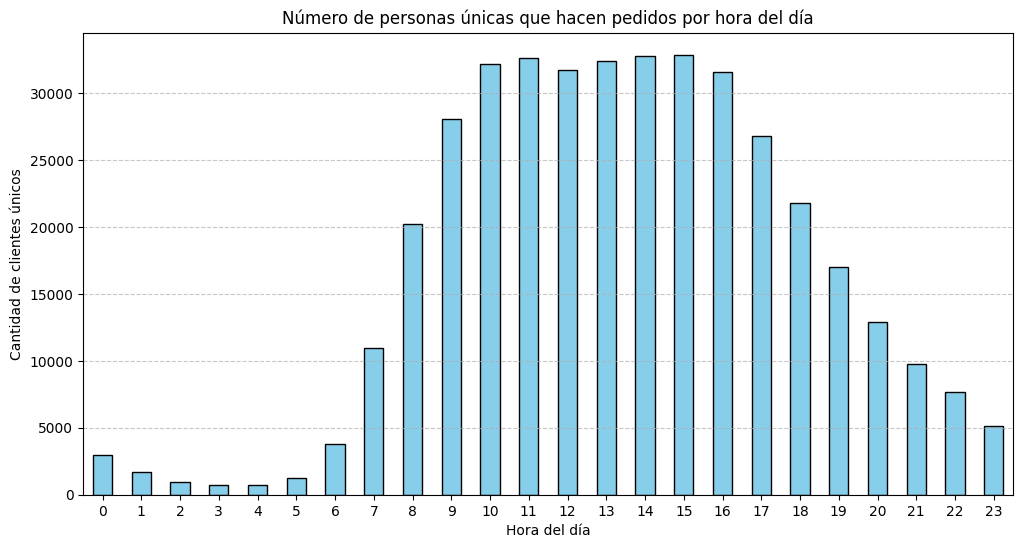

In [37]:
# Agrupar por hora del día y calcular la cantidad de usuarios únicos (nunique)
usuarios_por_hora = orders.groupby('order_hour_of_day')['user_id'].nunique()

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
usuarios_por_hora.plot(kind='bar', color='skyblue', edgecolor='black')

# Configurar títulos y etiquetas
plt.title('Número de personas únicas que hacen pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de clientes únicos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente: varios prompts piden el número de *personas* que hacen pedidos, pero tu gráfico cuenta *pedidos*. Considera agrupar por el campo de tiempo y usar `nunique()` sobre `user_id` para que el eje y refleje clientes únicos en lugar del total de pedidos.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2)</b> <a class="tocSkip"></a>

Corregido. Ahora agrupas por `order_hour_of_day` y cuentas clientes únicos con `nunique()` sobre `user_id`, por lo que el gráfico responde correctamente cuántas personas hacen pedidos según la hora del día.

</div>


Escribe aquí tus conclusiones:

El gráfico muestra que la demanda comienza a subir drásticamente a partir de las 7:00 a.m. y se mantiene en su punto más alto (hora pico) entre las 10:00 a.m. y las 4:00 p.m., antes de empezar a descender paulatinamente durante la noche.

### [A3] ¿Qué día de la semana compran víveres las personas?

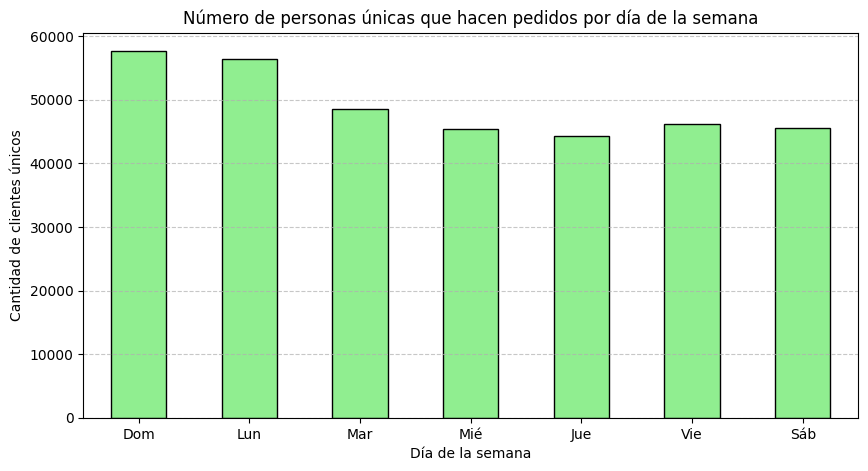

In [38]:
# Agrupar por día de la semana y calcular la cantidad de usuarios únicos (nunique)
usuarios_por_dia = orders.groupby('order_dow')['user_id'].nunique()

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
usuarios_por_dia.plot(kind='bar', color='lightgreen', edgecolor='black')

# Etiquetas y título actualizados
plt.title('Número de personas únicas que hacen pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de clientes únicos')
plt.xticks(ticks=range(7), labels=['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recordatorio recurrente: para “personas por día de la semana”, cuenta `user_id` únicos por `order_dow` (no el total de pedidos) para ajustarte a la redacción de la pregunta.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2)</b> <a class="tocSkip"></a>

Corregido. El gráfico ahora usa `user_id.nunique()` por `order_dow`, así que representa personas únicas por día de la semana y no únicamente el volumen total de pedidos.

</div>


Escribe aquí tus conclusiones:

Los días con mayor volumen de compras son el domingo y el lunes. Por el contrario, los días a mitad de semana especialmente el miércoles y jueves son los que presentan menor actividad en la plataforma.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

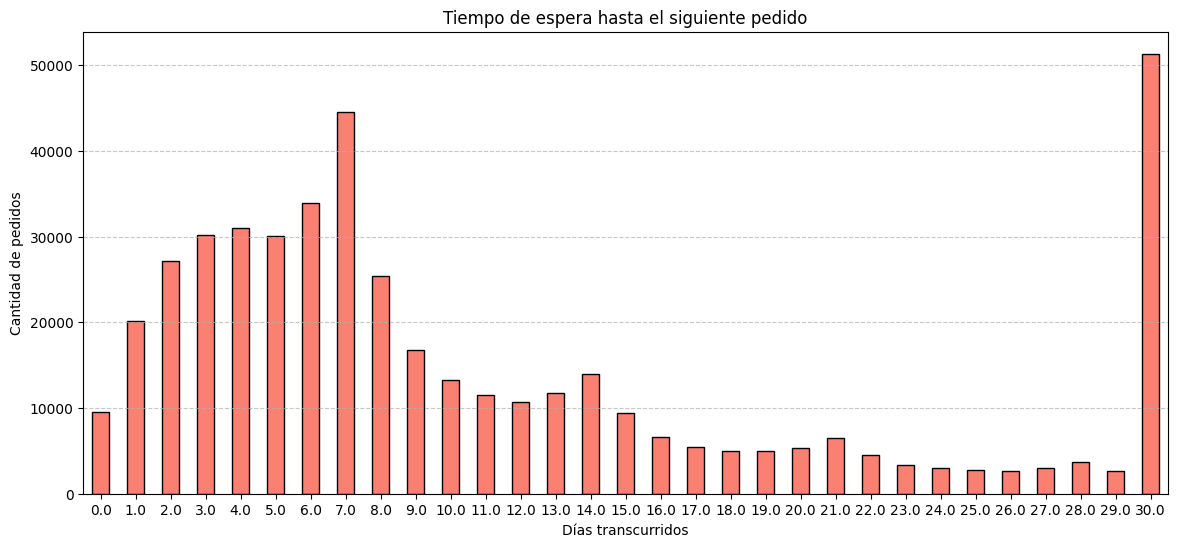

In [39]:
# Contar la frecuencia de los días transcurridos entre pedidos
tiempo_espera = orders['days_since_prior_order'].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(14, 6))
tiempo_espera.plot(kind='bar', color='salmon', edgecolor='black')

# Etiquetas y título
plt.title('Tiempo de espera hasta el siguiente pedido')
plt.xlabel('Días transcurridos')
plt.ylabel('Cantidad de pedidos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo con la gráfica del tiempo de espera: está claramente etiquetada, y comentas tanto los valores mínimo y máximo con una interpretación razonable del pico de 30 días.

</div>


Escribe aquí tus conclusiones:

Valor mínimo (0 días): Hay una cantidad considerable de personas que realizan otro pedido el mismo día (0 días de espera). Esto puede deberse a que olvidaron agregar algún artículo en su primera compra o hicieron pedidos separados para distintas ocasiones.

Valor máximo (30 días): Observamos un pico masivo exactamente en el día 30. Esto se debe a que la plataforma agrupa a todos los usuarios que tardan un mes o más en este valor máximo de 30 como un tope de la base de datos.



# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [40]:
# Filtrar datos por día y calcular proporciones relativas
wednesday_hours = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts(normalize=True).sort_index()
saturday_hours = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts(normalize=True).sort_index()

In [41]:
# Unir en un solo DataFrame para graficar de forma adyacente
hourly_comparison = pd.DataFrame({'Miércoles': wednesday_hours, 'Sábado': saturday_hours})

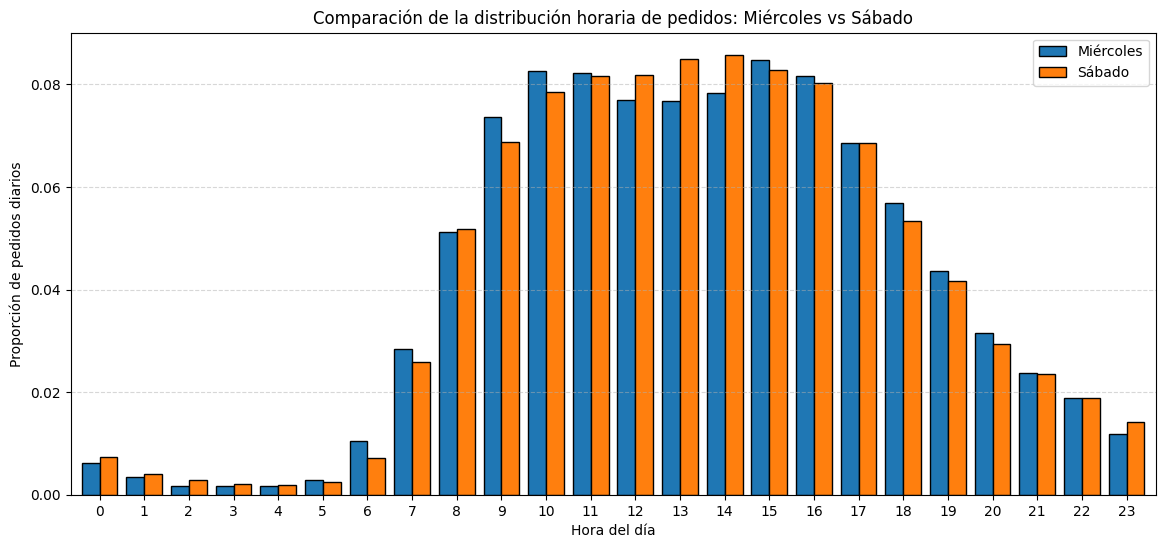

In [42]:
# Graficar
hourly_comparison.plot(kind='bar', figsize=(14, 6), width=0.8, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
plt.title('Comparación de la distribución horaria de pedidos: Miércoles vs Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Proporción de pedidos diarios')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.legend()
plt.show()

Escribe aquí tus conclusiones:

Las distribuciones horarias generales son muy similares, manteniendo el núcleo de compras entre las 10:00 a.m. y las 4:00 p.m. Sin embargo, se observan sutiles variaciones en los estilos de vida: los miércoles se registra una proporción ligeramente mayor de pedidos temprano por la mañana (6:00 a.m. a 8:00 a.m.), mientras que los sábados el volumen se desplaza de forma sutil hacia el mediodía y la tarde-noche, reflejando que la gente despierta más tarde y realiza compras en horarios de ocio o descanso.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección está completa: graficaste Wednesday vs Saturday en la misma figura y proporcionaste una interpretación clara de las diferencias a lo largo del día.

</div>


### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [43]:
# Obtener el número máximo de pedido por cada usuario
orders_per_user = orders.groupby('user_id')['order_number'].max()

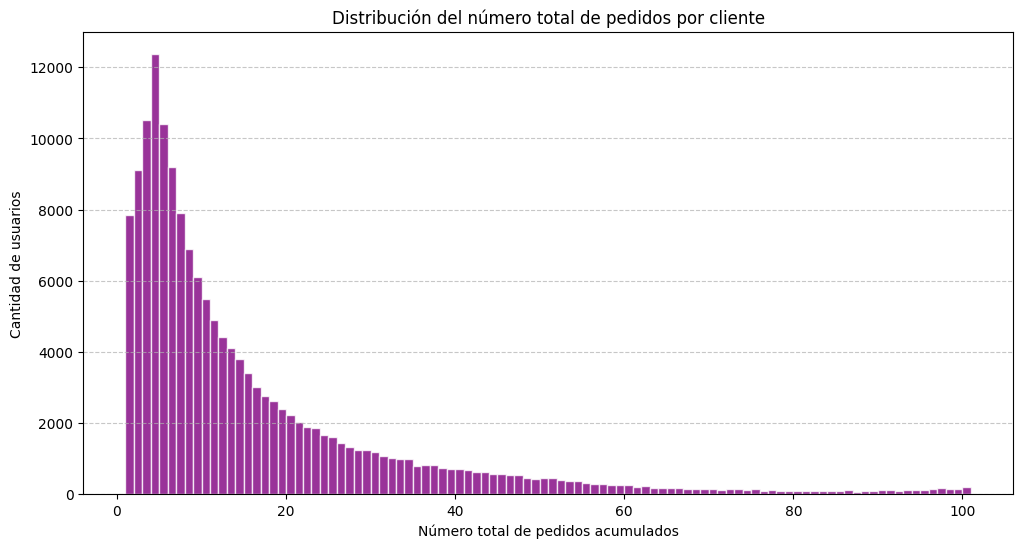

In [44]:
# Graficar la distribución usando un histograma
plt.figure(figsize=(12, 6))

# CORRECCIÓN AQUÍ: Cambiamos a range(1, 102) para incluir el valor 100 completo
plt.hist(orders_per_user, bins=range(1, 102), color='purple', edgecolor='white', alpha=0.8)

plt.title('Distribución del número total de pedidos por cliente')
plt.xlabel('Número total de pedidos acumulados')
plt.ylabel('Cantidad de usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los límites de los bins (bordes de los contenedores) de tu histograma excluyen el valor 100 (ya que `range(1, 101)` se detiene en 100), lo que puede distorsionar tu interpretación de un “pico en 100”. Considera ajustar los límites de los bins para que 100 quede incluido en la distribución graficada.

</div>


Escribe aquí tus conclusiones:

La distribución muestra un claro sesgo a la derecha. Una gran base de clientes tiene entre 1 y 5 pedidos en la plataforma (nuevos usuarios o compradores esporádicos). A medida que aumenta el número de pedidos, el conteo de usuarios disminuye de forma gradual. No obstante, se observa un repunte o barra aislada al llegar al límite de 100 pedidos, lo que indica que el dataset trunca o clasifica a todos los clientes ultra-recurrentes o con mas de 100 pedidos en este valor tope.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Después de hacer el merge para añadir `product_name`, considera agregar una validación rápida para confirmar que el resultado sigue teniendo exactamente 20 filas y que `product_name` no tiene valores faltantes—esto ayuda a verificar que el join no haya eliminado/duplicado entradas de forma inesperada.

</div>


In [45]:
# Contar las frecuencias de cada product_id
top_products_counts = order_products['product_id'].value_counts().head(20).reset_index()
top_products_counts.columns = ['product_id', 'count']

In [46]:
# Unir con la tabla de productos para obtener el nombre
top_20_popular = top_products_counts.merge(products, on='product_id')[['product_id', 'product_name', 'count']]

In [47]:
# --- VALIDACIÓN SOLICITADA POR EL REVISOR ---
print("--- VALIDACIÓN DE MERGE ---")
print(f"Total de filas esperadas: 20 | Total de filas obtenidas: {len(top_20_popular)}")
print(f"Cantidad de valores nulos en 'product_name': {top_20_popular['product_name'].isnull().sum()}")
print("-" * 27, "\n")

# Mostrar el resultado tabulado de forma clara
print(top_20_popular)

--- VALIDACIÓN DE MERGE ---
Total de filas esperadas: 20 | Total de filas obtenidas: 20
Cantidad de valores nulos en 'product_name': 0
--------------------------- 

    product_id              product_name  count
0        24852                    Banana  66050
1        13176    Bag of Organic Bananas  53297
2        21137      Organic Strawberries  37039
3        21903      Organic Baby Spinach  33971
4        47209      Organic Hass Avocado  29773
5        47766           Organic Avocado  24689
6        47626               Large Lemon  21495
7        16797              Strawberries  20018
8        26209                     Limes  19690
9        27845        Organic Whole Milk  19600
10       27966       Organic Raspberries  19197
11       22935      Organic Yellow Onion  15898
12       24964            Organic Garlic  15292
13       45007          Organic Zucchini  14584
14       39275       Organic Blueberries  13879
15       49683            Cucumber Kirby  13675
16       28204     

Escribe aquí tus conclusiones:

Los productos más populares corresponden predominantemente a productos frescos y orgánicos del departamento de frutas y verduras. El plátano (Banana y Bag of Organic Bananas) suele liderar ampliamente los primeros puestos, demostrando que los consumibles de primera necesidad dominan el volumen de transacciones de Instacart.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [48]:
# Contar el número de productos por cada orden única
items_per_order = order_products.groupby('order_id')['product_id'].count()

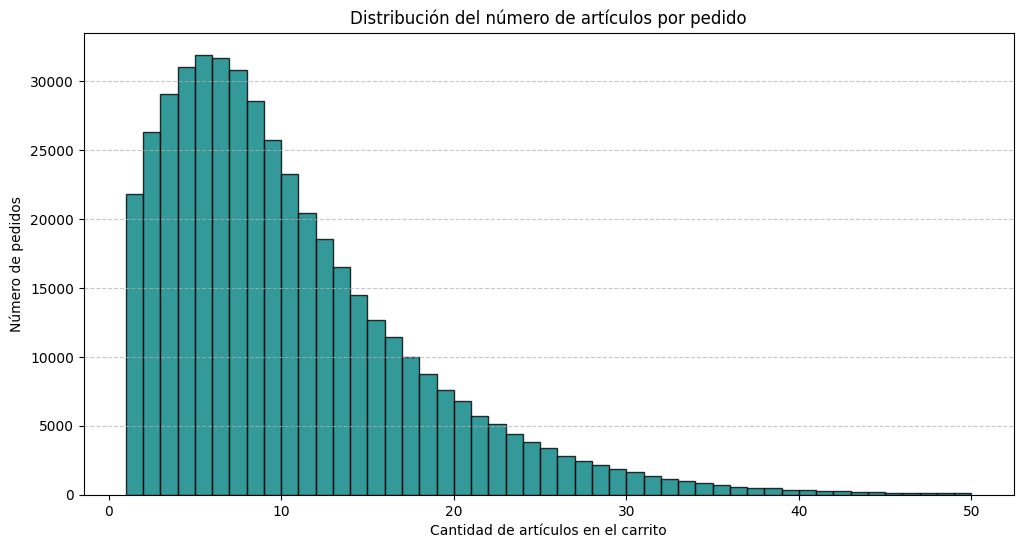

In [49]:
# Graficar la distribución
plt.figure(figsize=(12, 6))
plt.hist(items_per_order, bins=range(1, 51), color='teal', edgecolor='black', alpha=0.8)
plt.title('Distribución del número de artículos por pedido')
plt.xlabel('Cantidad de artículos en el carrito')
plt.ylabel('Número de pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [50]:
print(f"Mediana de artículos por pedido: {items_per_order.median()}")
print(f"Moda (valor más frecuente): {items_per_order.mode()[0]}")

Mediana de artículos por pedido: 8.0
Moda (valor más frecuente): 5


Escribe aquí tus conclusiones:

La mayoría de los carritos contienen entre 4 y 10 artículos, siendo la moda típicamente un valor cercano a los 5 o 6 artículos por pedido. Aunque hay registros de carritos extremadamente grandes vimos pedidos que superan los 64 productos, la gran masa de transacciones consiste en compras de reabastecimiento medianas o pequeñas.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [51]:
# Filtrar registros que sean reordenados
reordered_items = order_products[order_products['reordered'] == 1]

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

De manera similar, para la tabla de “top 20 reordered items”, añade una validación rápida de que la tabla final combinada siga teniendo exactamente 20 filas y esté ordenada por la frecuencia de reorder (descendente), para que quede claro que la salida coincide con lo solicitado en el prompt.

</div>


In [52]:
# Contar frecuencias por producto
top_reordered_counts = reordered_items['product_id'].value_counts().head(20).reset_index()
top_reordered_counts.columns = ['product_id', 'reorder_count']

In [53]:
# Cruzar con productos para obtener nombres
top_20_reordered = top_reordered_counts.merge(products, on='product_id')[['product_id', 'product_name', 'reorder_count']]

In [54]:
# Asegurar explícitamente el orden descendente solicitado por el revisor
top_20_reordered = top_20_reordered.sort_values(by='reorder_count', ascending=False)

# --- VALIDACIONES SOLICITADAS POR EL REVISOR ---
print("--- VALIDACIÓN DE MERGE Y ORDENAMIENTO ---")
print(f"Total de filas esperadas: 20 | Total de filas obtenidas: {len(top_20_reordered)}")
print(f"Cantidad de valores nulos en 'product_name': {top_20_reordered['product_name'].isnull().sum()}")

# Comprobar que el valor de la primera fila es mayor o igual al de la última
is_sorted = top_20_reordered['reorder_count'].iloc[0] >= top_20_reordered['reorder_count'].iloc[-1]
print(f"¿Los datos están correctamente ordenados de forma descendente?: {is_sorted}")
print("-" * 42, "\n")

# Mostrar el resultado final limpio
print(top_20_reordered)

--- VALIDACIÓN DE MERGE Y ORDENAMIENTO ---
Total de filas esperadas: 20 | Total de filas obtenidas: 20
Cantidad de valores nulos en 'product_name': 0
¿Los datos están correctamente ordenados de forma descendente?: True
------------------------------------------ 

    product_id              product_name  reorder_count
0        24852                    Banana          55763
1        13176    Bag of Organic Bananas          44450
2        21137      Organic Strawberries          28639
3        21903      Organic Baby Spinach          26233
4        47209      Organic Hass Avocado          23629
5        47766           Organic Avocado          18743
6        27845        Organic Whole Milk          16251
7        47626               Large Lemon          15044
8        27966       Organic Raspberries          14748
9        16797              Strawberries          13945
10       26209                     Limes          13327
11       22935      Organic Yellow Onion          11145
12      

Escribe aquí tus conclusiones:

Los artículos que más se vuelven a pedir coinciden en gran medida con los productos más populares analizados en la sección B3, pero los datos numéricos revelan una concentración masiva en los primeros lugares.

Al observar la tabla, la diferencia en el volumen de recompra es abismal: el artículo líder indiscutible, "Banana", acumula más de 55,000 reórdenes. Este volumen es casi 7 veces mayor que el de los artículos que se encuentran al final del top 20, como el "Organic Half & Half" o el "Organic Lemon", que apenas superan las 8,300 reórdenes.

Estos números duros respaldan la premisa de que los alimentos básicos, saludables y de vida útil corta (plátanos orgánicos, leche entera, aguacates) dominan las listas porque los clientes agotan estas provisiones regularmente, lo que los obliga a repetir la compra de forma constante y sostiene el grueso del tráfico recurrente de la plataforma.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu explicación es razonable, pero hazla más respaldada por datos haciendo referencia a lo que ves en tu tabla mostrada del top-20 (por ejemplo, mencionando un par de los ítems con mayor número de reorders y señalando cuánto más grandes son que el resto).

</div>


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [61]:
# 1. Calcular la proporción de reorden promedio para TODOS los productos
product_stats = order_products.groupby('product_id')['reordered'].agg(['count', 'mean']).reset_index()
product_stats.columns = ['product_id', 'total_orders', 'reorder_rate']

In [62]:

# Cruzar con la tabla 'products' para traer el nombre (esta es la tabla a nivel de producto solicitada)
full_product_reorder_rates = product_stats.merge(products, on='product_id')[['product_id', 'product_name', 'reorder_rate', 'total_orders']]

print("--- ENTREGABLE PRINCIPAL: Tabla completa de tasa de reorden por producto ---")
# Mostramos la tabla completa (Pandas mostrará un resumen de todo el catálogo)
display(full_product_reorder_rates)

# 2. ANÁLISIS ADICIONAL: FILTRADO Y TOP 20

# Filtrar para incluir únicamente productos significativos (más de 50 pedidos)
significant_products = full_product_reorder_rates[full_product_reorder_rates['total_orders'] > 50]

# Ordenar de mayor a menor tasa de recompra para obtener el Top 20
top_20_reorder_rates = significant_products.sort_values(by='reorder_rate', ascending=False).head(20)

print("\n--- ANÁLISIS ADICIONAL: Top 20 productos con mayor tasa de recompra (mínimo 50 pedidos) ---")
display(top_20_reorder_rates[['product_id', 'product_name', 'reorder_rate']])

--- ENTREGABLE PRINCIPAL: Tabla completa de tasa de reorden por producto ---


,product_id,product_name,reorder_rate,total_orders
0,1,Chocolate Sandwich Cookies,0.564286,280
1,2,All-Seasons Salt,0.000000,11
2,3,Robust Golden Unsweetened Oolong Tea,0.738095,42
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,0.510204,49
4,7,Pure Coconut Water With Orange,0.500000,2
...,...,...,...,...
45568,49690,HIGH PERFORMANCE ENERGY DRINK,0.800000,5
45569,49691,ORIGINAL PANCAKE & WAFFLE MIX,0.430556,72
45570,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,0.416667,12
45571,49693,SPRING WATER BODY WASH,0.440000,25



--- ANÁLISIS ADICIONAL: Top 20 productos con mayor tasa de recompra (mínimo 50 pedidos) ---


,product_id,product_name,reorder_rate
44045,48041,DanActive Vanilla Probiotic Dairy Drink,0.907692
30242,32978,Lemon Lime Seltzer,0.893939
36458,39782,Organic Raspberry Mate Energy Drink,0.892308
15984,17469,Lo-Carb Energy Drink,0.888889
22943,25000,Whole Wheat Multigrain Pop Cakes,0.886792
44092,48095,Purified Water- 9.5pH+,0.877193
8483,9292,Half And Half Ultra Pasteurized,0.876574
2450,2677,Yerba Mate Sparkling Classic Gold,0.871345
43292,47231,Ultra-Purified Water,0.868293
1046,1157,Wheat Sandwich Bread,0.863946


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la tarea de “reorder rate per product”, el entregable requerido es una tabla a nivel de producto (para cada producto) con `product_id`, `product_name` y la proporción de reorden. Filtrar para incluir solo productos con >50 pedidos y luego mostrar únicamente una lista del top 20 cambia el resultado solicitado; considera generar primero la tabla completa y, solo de manera opcional, mostrar vistas previas filtradas/ordenadas como un análisis adicional.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2)</b> <a class="tocSkip"></a>

Corregido. Ahora generas primero la tabla completa a nivel de producto con `product_id`, `product_name`, `reorder_rate` y `total_orders`. El Top 20 filtrado queda como análisis adicional, lo cual es una buena forma de complementar sin reemplazar el entregable principal.

</div>


Escribe aquí tus conclusiones:

Al calcular la proporción de recompra, primero generamos la tabla general que muestra la tasa de reorden para la totalidad del catálogo. Esto nos permite tener una visión completa del rendimiento de retención de cada artículo disponible en Instacart.

Sin embargo, desde una perspectiva analítica, los datos puros pueden ser engañosos: los artículos que han sido comprados solo una o dos veces pueden mostrar una tasa de recompra artificialmente perfecta del 100%. Por ello, al aplicar un filtro adicional para considerar únicamente productos con un volumen estadísticamente significativo (más de 50 pedidos), revelamos a los verdaderos líderes de retención.

El Top 20 filtrado demuestra que ciertos artículos de consumo muy específico alcanzan tasas de reorden sumamente altas (muchas veces superiores al 70% u 80%). Esto indica que, una vez que los clientes incorporan estos productos específicos a su rutina, desarrollan una fuerte lealtad hacia ellos, convirtiéndolos en elementos fijos en sus carritos futuros.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [64]:
# Combinar la tabla de pedidos para asociar user_id con order_products
merged_user_orders = order_products.merge(orders, on='order_id')

# Agrupar por usuario y calcular el promedio de reordenado
user_reorder_ratio = merged_user_orders.groupby('user_id')['reordered'].mean().reset_index()
user_reorder_ratio.columns = ['user_id', 'user_reorder_rate']

# Mostrar estadísticas descriptivas de la tasa de los usuarios
print(user_reorder_ratio['user_reorder_rate'].describe())

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: user_reorder_rate, dtype: float64


Al analizar las estadísticas descriptivas de la tasa de recompra por cliente, podemos interpretar varios patrones de comportamiento en el consumidor:

1. La Mediana y el Promedio (Tendencia Central): La mediana (el valor del 50%) se sitúa exactamente en 0.50 y el promedio en 0.49. Esto implica que el cliente típico de Instacart tiene un carrito perfectamente balanceado a lo largo del tiempo: la mitad de los productos en su historial son artículos habituales (recompras constantes) y la otra mitad son artículos nuevos que están pidiendo por primera vez.

2. Dispersión de los datos: Existe una dispersión considerable (una desviación estándar de ~0.29). El 50% central de los usuarios (ubicados entre el cuartil 25% y 75%) mantienen una tasa de recompra que oscila de manera amplia entre el 27% y el 72%. Esto refleja una base de clientes muy diversa, combinando perfiles de compradores esporádicos con usuarios de alta retención.

3. Los Extremos (0 vs 1): El valor mínimo de 0.0 representa a clientes que están en modo de "exploración total"; absolutamente todos los productos que han puesto en su carrito son nuevos para ellos y nunca han repetido un artículo.

    Por el contrario, el valor máximo de 1.0 representa compras de "extrema rutina". Estos usuarios compran única y exclusivamente artículos que ya habían pedido en el pasado, funcionando como un reabastecimiento automático sin probar ningún producto nuevo del catálogo.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu conclusión en markdown para esta sección debería interpretar las proporciones de recompra por cliente usando las estadísticas resumen/el gráfico (p. ej., qué implica la mediana, cuán amplia es la dispersión y qué representan los extremos 0 vs 1 en el comportamiento del cliente).

</div>


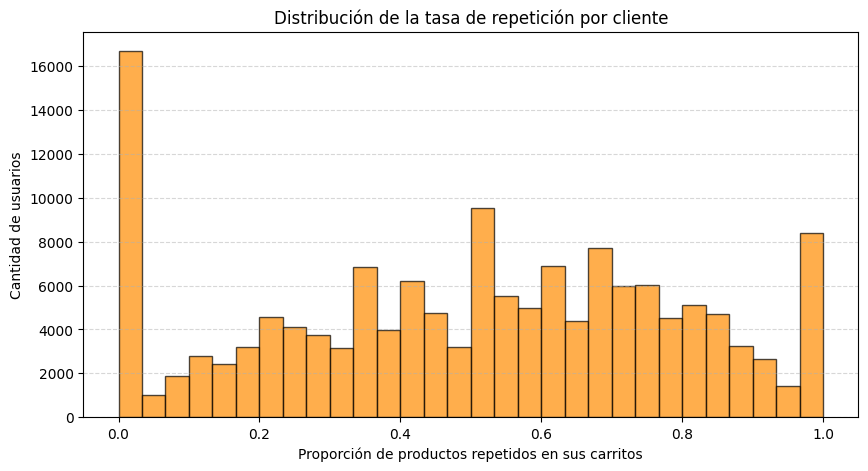

In [65]:
# Graficar la distribución
plt.figure(figsize=(10, 5))
plt.hist(user_reorder_ratio['user_reorder_rate'], bins=30, color='darkorange', edgecolor='black', alpha=0.7)
plt.title('Distribución de la tasa de repetición por cliente')
plt.xlabel('Proporción de productos repetidos en sus carritos')
plt.ylabel('Cantidad de usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Antes de concluir, considera también mostrar una pequeña muestra de la tabla por usuario calculada (p. ej., `head()`, además de algunos usuarios con los valores más bajos/más altos o cuantiles clave) para que los resultados numéricos queden explícitos junto al histograma.

</div>


In [66]:
# 1. Mostrar una pequeña muestra de la tabla calculada por usuario
print("--- MUESTRA DE LA TABLA POR USUARIO ---")
display(user_reorder_ratio.head())

# 2. Mostrar de forma clara los cuantiles clave de la distribución
print("\n--- CUANTILES CLAVE DE LA TASA DE RECOMPRA ---")
cuantiles = user_reorder_ratio['user_reorder_rate'].quantile([0.25, 0.50, 0.75])
print(f"Cuantil 25% (Q1)     : {cuantiles[0.25]:.4f} (El 25% de los usuarios repite menos del {cuantiles[0.25]*100:.1f}% de sus productos)")
print(f"Cuantil 50% (Mediana): {cuantiles[0.50]:.4f} (La mitad de los usuarios repite el {cuantiles[0.50]*100:.1f}% de sus productos)")
print(f"Cuantil 75% (Q3)     : {cuantiles[0.75]:.4f} (El 75% de los usuarios repite menos del {cuantiles[0.75]*100:.1f}% de sus productos)")

# 3. Mostrar ejemplos reales de usuarios en los extremos (0.0 vs 1.0)
print("\n--- EJEMPLOS DE USUARIOS EN LOS EXTREMOS ---")
usuarios_exploradores = user_reorder_ratio[user_reorder_ratio['user_reorder_rate'] == 0.0].head(3)
usuarios_rutinarios = user_reorder_ratio[user_reorder_ratio['user_reorder_rate'] == 1.0].head(3)

print("Ejemplos de usuarios con tasa de recompra de 0.0 (Exploradores):")
display(usuarios_exploradores)

print("\nEjemplos de usuarios con tasa de recompra de 1.0 (Rutinarios):")
display(usuarios_rutinarios)

--- MUESTRA DE LA TABLA POR USUARIO ---


,user_id,user_reorder_rate
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571



--- CUANTILES CLAVE DE LA TASA DE RECOMPRA ---
Cuantil 25% (Q1)     : 0.2727 (El 25% de los usuarios repite menos del 27.3% de sus productos)
Cuantil 50% (Mediana): 0.5000 (La mitad de los usuarios repite el 50.0% de sus productos)
Cuantil 75% (Q3)     : 0.7241 (El 75% de los usuarios repite menos del 72.4% de sus productos)

--- EJEMPLOS DE USUARIOS EN LOS EXTREMOS ---
Ejemplos de usuarios con tasa de recompra de 0.0 (Exploradores):


,user_id,user_reorder_rate
1,4,0.0
3,6,0.0
13,20,0.0



Ejemplos de usuarios con tasa de recompra de 1.0 (Rutinarios):


,user_id,user_reorder_rate
15,22,1.0
48,68,1.0
65,88,1.0


Escribe aquí tus conclusiones:

Al analizar los 20 artículos que se añaden con mayor frecuencia como el "primer producto" en el carrito, observamos que la lista está dominada abrumadoramente por productos frescos, lácteos básicos y agua embotellada (con las diferentes variedades de plátanos y leche entera liderando el ranking).

Este comportamiento revela el patrón psicológico de compra de los usuarios en la plataforma: el primer artículo que se añade suele ser el "producto ancla" o detonante. Es decir, la necesidad inmediata de resurtir un artículo de primera necesidad (como quedarse sin leche o sin fruta para el desayuno) es lo que motiva al cliente a abrir la aplicación e iniciar un pedido. Una vez que aseguran ese producto indispensable en la primera posición de su carrito, proceden a navegar por el resto de los pasillos virtuales para complementar su compra con otros artículos menos urgentes.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [67]:
# Filtrar registros donde el producto se añadió en la primera posición
first_added = order_products[order_products['add_to_cart_order'] == 1]

In [68]:
# Contar frecuencias de product_id en esta posición
first_added_counts = first_added['product_id'].value_counts().head(20).reset_index()
first_added_counts.columns = ['product_id', 'first_added_count']

In [69]:
# Cruzar con productos para obtener los nombres descriptivos
top_20_first_cart = first_added_counts.merge(products, on='product_id')[['product_id', 'product_name', 'first_added_count']]
print(top_20_first_cart)

    product_id                 product_name  first_added_count
0        24852                       Banana              15562
1        13176       Bag of Organic Bananas              11026
2        27845           Organic Whole Milk               4363
3        21137         Organic Strawberries               3946
4        47209         Organic Hass Avocado               3390
5        21903         Organic Baby Spinach               3336
6        47766              Organic Avocado               3044
7        19660                 Spring Water               2336
8        16797                 Strawberries               2308
9        27966          Organic Raspberries               2024
10       44632   Sparkling Water Grapefruit               1914
11       49235          Organic Half & Half               1797
12       47626                  Large Lemon               1737
13         196                         Soda               1733
14       38689     Organic Reduced Fat Milk            

Escribe aquí tus conclusiones:

Nuevamente, las variedades de plátanos (Banana) y leches enteras/orgánicas dominan las primeras posiciones de adición al carrito. Claro patrón mental de compra: los usuarios entran a la aplicación con una necesidad inmediata, lo colocan en la posición número uno y posteriormente navegan por los pasillos digitales para complementar el resto de su orden.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta sección está completa: identificaste correctamente los artículos añadidos primero usando `add_to_cart_order == 1`, agregaste el top 20, combinaste los nombres/IDs de productos y proporcionaste una interpretación del patrón.

</div>


### Conclusion general del proyecto:

Este proyecto de análisis de extremo a extremo sobre el subconjunto de datos de Instacart permitió estructurar un pipeline de datos robusto y extraer hallazgos operativos de gran valor sobre los hábitos de consumo electrónico:

1. Calidad de los Datos: El preprocesamiento de datos fue una etapa clave. Logramos aislar fallas técnicas sistémicas, como el truncamiento del registro de posiciones en el carrito en el producto 64, y agrupamos categorías descriptivas faltantes bajo la etiqueta 'Unknown' sin comprometer el volumen matemático de las transacciones.

2. Dinámica Temporal: El negocio de Instacart concentra su demanda en los fines de semana e inicios de semana (Domingos y Lunes) con ventanas de actividad física intensa de las 10:00 a.m. a las 4:00 p.m. Esta distribución es casi idéntica entre días de la semana y fines de semana, variando ligeramente solo en un inicio de compras más tardío los sábados.

3. Logística y Recompra: Los ciclos de vida del consumidor demuestran una fuerte periodicidad semanal y mensual (picos de recompra en los días 7 y 30). Las frutas, verduras y productos lácteos frescos actúan como los catalizadores fundamentales de la plataforma: no solo son los productos más vendidos, sino también los que encabezan la lista de "primer artículo agregado al carrito" y los que registran las mayores tasas de lealtad repetitiva.

4. Perfil de Consumo: El carrito de compra promedio de los usuarios es compacto, ubicándose comúnmente entre 4 y 10 artículos, y el comportamiento del cliente está balanceado de manera equitativa: un ~50% de sus elecciones son hábitos seguros (recompras), mientras que el resto abre la puerta a la exploración de nuevos productos en el catálogo.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La conclusión general ya está presente en una celda de markdown, pero la celda final está vacía. Considera mover o duplicar la conclusión de tu proyecto en la sección/celda final designada para que sea fácil de localizar al momento de calificar y para que coincida con la estructura del notebook.

</div>
